# Convolution in pytorch

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

# !pip install torchvision
import torchvision

import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

In [ ]:
!pip install torchsummary
from torchsummary import summary

# HELP FUNCS

In [ ]:
def training_loop(model, n_epochs, optimizer, loss_fn, train_loader, scheduler):
  model.train()

  history = {
      "train_loss": [],
      "train_acc": [],
      "val_loss": [],
      "val_acc": [],
      "lambda": []
  }

  for epoch in range(n_epochs):
      loss_total = 0.0
      correct_total = 0
      sample_total = 0

      for images, labels in tqdm(train_loader, desc=f"Epoka: {epoch+1}"):

          optimizer.zero_grad()
          images = images.to(model.device)
          labels = labels.to(model.device)

          output = model(images)
          loss = loss_fn(output, labels)

          loss.backward()
          optimizer.step()

          # accuracy
          preds = output.argmax(dim=1)
          correct_total += (preds == labels).sum().item()
          sample_total += labels.size(0)

          # loss
          loss_total += loss.item()

      avg_loss = loss_total / len(train_loader)
      avg_acc  = correct_total / sample_total
      val_loss, val_acc = test_model(model=model, loss_fn=loss_fn, test_loader=val_dataloader)

      history["train_loss"].append(avg_loss)
      history["train_acc"].append(avg_acc)
      history["val_loss"].append(val_loss)
      history["val_acc"].append(val_acc)

      history["lambda"].append(optimizer.param_groups[0]['lr'])

      if(scheduler is not None):
        scheduler.step()

      print(f"Epoch {epoch+1}/{n_epochs}\n\t- Train loss: {avg_loss:.4f}\n\t- Train acc: {avg_acc:.4f}%\n\t- Val loss: {val_loss:.4f}\n\t- Val acc: {val_acc:.4f}%")
  return history


In [ ]:
def test_model(model, loss_fn, test_loader):
  model.eval()
  loss_total = 0.0
  correct_total = 0
  sample_total = 0

  for images, labels in test_loader:
    iamges = images.to(model.device)
    labels = labels.to(model.device)

    outputs = model(images)

    loss = loss_fn(outputs, labels)

    # accuracy
    preds = outputs.argmax(dim=1)
    correct_total += (preds == labels).sum().item()
    sample_total += labels.size(0)

    # loss
    loss_total += loss.item()

  avg_loss = loss_total / len(test_loader)
  avg_acc  = correct_total / sample_total
  return avg_loss, avg_acc


In [ ]:
def plot_history(history):
    """
    history = {
        "train_loss": [...],
        "train_acc": [...],
        "val_loss": [...],
        "val_acc": [...]
    }
    """

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12,5))

    # --- LOSS ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    if history["val_loss"][0] is not None:
        plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # --- ACCURACY ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    if history["val_acc"][0] is not None:
        plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.xticks(epochs)
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


def plot_history_lambda(history):
  epochs = range(1, len(history["train_loss"]) + 1)

  plt.plot(history['lambda'])
  plt.title("Lambda")
  plt.xlabel("Epoch")
  plt.ylabel("lambda")
  plt.xscale('linear')
  plt.xticks(epochs)
  plt.legend()
  plt.grid(True)
  plt.show()


# MODEL DEFINITION
---

In [ ]:
class CNN(nn.Module):
  def __init__(self, in_channels, num_classes, data_size, device, dropout_rate = 0.5):
    super().__init__()
    self.device = device

    self.conv_layers = nn.ModuleList([
      nn.Conv2d(in_channels=in_channels, out_channels=4, kernel_size=(3,3), stride=1, padding=1),
      nn.Conv2d(in_channels=4, out_channels=16, kernel_size=(3,3), stride=1, padding=1),
      nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3,3), stride=1, padding=1),
      nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3,3), stride=1, padding=1)
      #nn.Conv2d(in_channels=28, out_channels=32, kernel_size=(3,3), stride=1, padding=1)
      #nn.Conv2d(in_channels=32, out_channels=36, kernel_size=(3,3), stride=1, padding=1)
    ])

    self.dropout = nn.Dropout(p=dropout_rate)

    self.maxPool = nn.MaxPool2d(kernel_size=(2,2), stride=2)
    self.flatten = nn.Flatten()

    # computing the final layer size
    example_input = torch.zeros(1, in_channels, data_size[0], data_size[1]).to(device)
    self.to(self.device)
    linear_in = self.__calculate_output_size(example_input)

    self.output_ffnn = nn.Linear(in_features=linear_in, out_features=10)

    self.to(self.device)



  def __calculate_output_size(self, input):
    input = input.to(self.device)

    output = input

    for conv_layer in self.conv_layers:
      output = conv_layer(output)
      output = F.relu(output)
      output = self.maxPool(output)

    return output.shape[1]*output.shape[2]*output.shape[3]



  def forward(self, input):
    input = input.to(self.device)
    output = input

    # dense conv layers
    for conv_layer in self.conv_layers:
      output = conv_layer(output)
      output = F.relu(output)
      output = self.maxPool(output)

    # ffnn step
    output = self.flatten(output)
    output = self.output_ffnn(output)

    return output

# LOADING AND PREPROCCESSING DATA SET

In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

mnist_train = datasets.CIFAR10(root='data', train=True, download=True, transform=transform);
mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [45000, 5000])

train_dataloader = DataLoader(mnist_train, batch_size=32, shuffle=True);
val_dataloader = DataLoader(mnist_val, batch_size=5000);

mnist_test = datasets.CIFAR10(root='data', train=False, download=True, transform=transform);

test_dataloader = DataLoader(mnist_test);

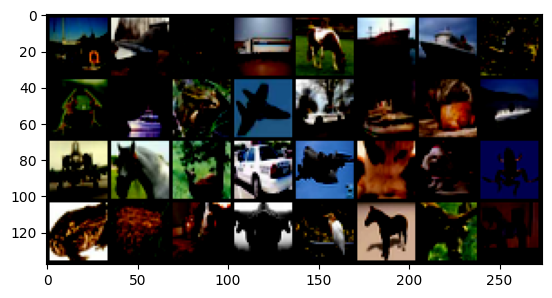

In [ ]:
def imshow(img):
   npimg = img.numpy()
   plt.imshow(npimg.transpose((1, 2, 0)))
   plt.show()

# get some random training images
dataiter = iter(train_dataloader)
images, labels = next(dataiter)
labels
imshow(torchvision.utils.make_grid(images))

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN(in_channels=3, num_classes=10, data_size=(32,32), device=device)
summary(model, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 32, 32]             112
         MaxPool2d-2            [-1, 4, 16, 16]               0
            Conv2d-3           [-1, 16, 16, 16]             592
         MaxPool2d-4             [-1, 16, 8, 8]               0
            Conv2d-5             [-1, 32, 8, 8]           4,640
         MaxPool2d-6             [-1, 32, 4, 4]               0
            Conv2d-7             [-1, 64, 4, 4]          18,496
         MaxPool2d-8             [-1, 64, 2, 2]               0
           Flatten-9                  [-1, 256]               0
           Linear-10                   [-1, 10]           2,570
Total params: 26,410
Trainable params: 26,410
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.11
Params size (MB): 0.10
Estimated Tot

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.9)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda epoch: 0.95**epoch)

history = training_loop(model, 15, optimizer=optimizer, loss_fn=loss_fn, train_loader=train_dataloader, scheduler=scheduler)

Epoka: 1: 100%|██████████| 1407/1407 [00:15<00:00, 89.16it/s]


Epoch 1/15
	- Train loss: 1.1152
	- Train acc: 0.6035%
	- Val loss: 1.1110
	- Val acc: 0.6038%


Epoka: 2: 100%|██████████| 1407/1407 [00:13<00:00, 102.84it/s]


Epoch 2/15
	- Train loss: 1.0411
	- Train acc: 0.6318%
	- Val loss: 1.0850
	- Val acc: 0.6198%


Epoka: 3: 100%|██████████| 1407/1407 [00:15<00:00, 92.19it/s] 


...

Epoch 13/15
	- Train loss: 0.7045
	- Train acc: 0.7529%
	- Val loss: 1.0043
	- Val acc: 0.6564%


Epoka: 14: 100%|██████████| 1407/1407 [00:13<00:00, 104.48it/s]


Epoch 14/15
	- Train loss: 0.6853
	- Train acc: 0.7608%
	- Val loss: 1.0375
	- Val acc: 0.6516%


Epoka: 15: 100%|██████████| 1407/1407 [00:13<00:00, 103.38it/s]


Epoch 15/15
	- Train loss: 0.6703
	- Train acc: 0.7648%
	- Val loss: 1.0397
	- Val acc: 0.6586%


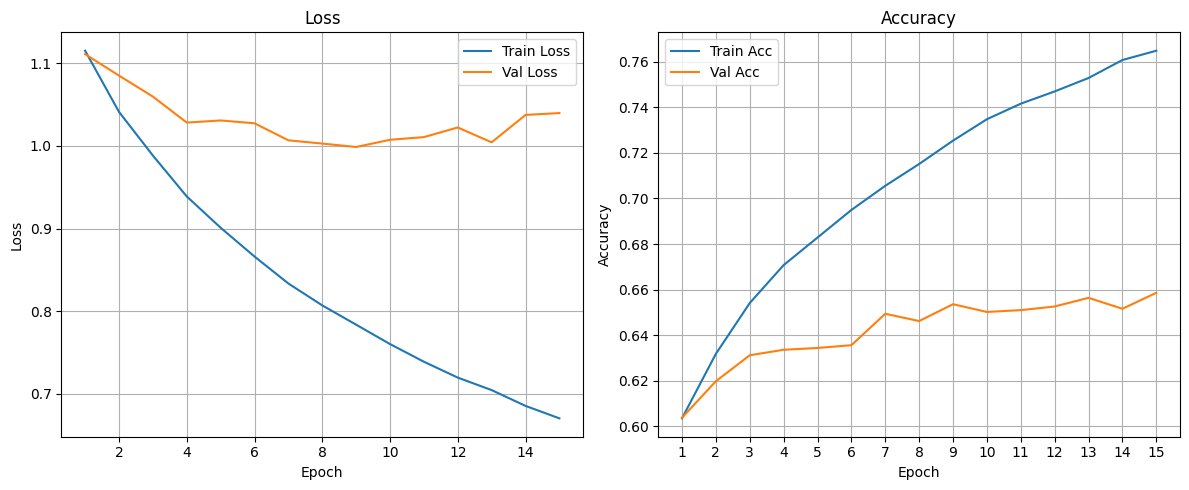

In [ ]:
plot_history(history)

/tmp/ipython-input-324304126.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


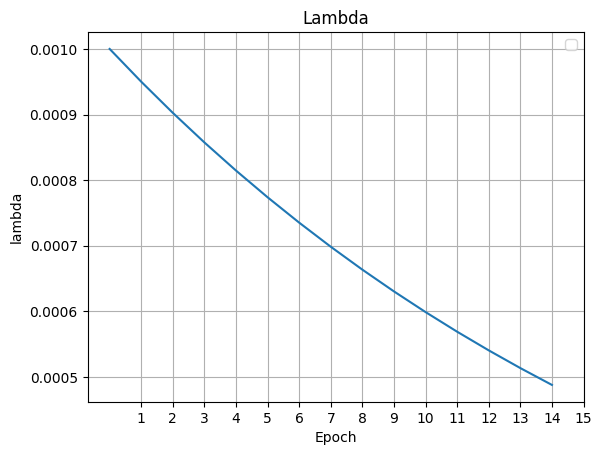

In [ ]:
plot_history_lambda(history)

In [ ]:
test_loss,test_acc = test_model(model, loss_fn, test_loader=test_dataloader)
print(f"Test koncowy:\nTest loss: {test_loss:.4f}\nTest acc: {test_acc:.4f}")

Test koncowy:
Test loss: 1.0400
Test acc: 0.6600
